# Practica 2: señales y sistemas discretos

Estudiante: Mariana Vásquez Ramírez

Resumen: 
¿Qué hicimos?
¿Cómo lo hicimos?
¿Cuál fue el dato mas importante que obtuvimos?

In [65]:
#Importamos librerias necesarias
import numpy as np
import matplotlib.pyplot as plt

EJEMPLOS DE CLASE:

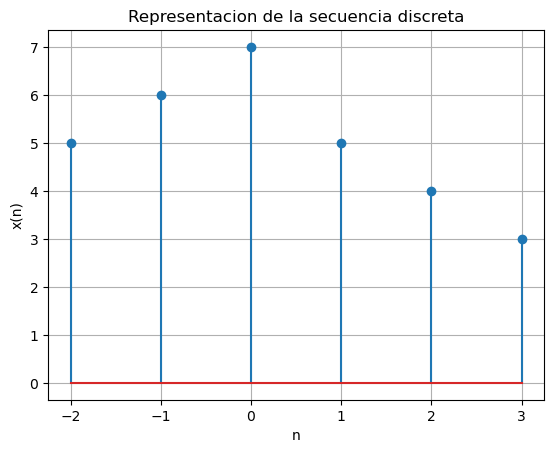

In [66]:
n = np.array([-2,-1,0,1,2,3])   #vector de posiciones 
x = np.array([5,6,7,5,4,3]) #el gorrito del 7 indica que ahi empiza la posicion 0

#graficamos 
plt.stem(n,x)
plt.xlabel('n')
plt.ylabel('x(n)')
plt.title('Representacion de la secuencia discreta')
plt.grid(True)

x: [False False False False False  True False False False False False]
n: [-5 -4 -3 -2 -1  0  1  2  3  4  5]


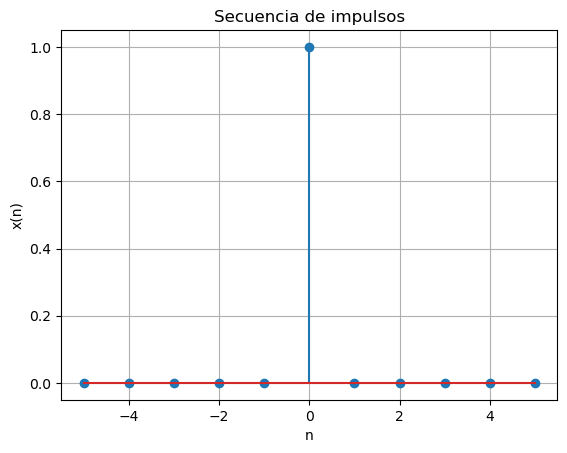

In [67]:
def impseq(n0, n1, n2):
    """ genera una señal secuencia de impulsos de la forma x(n) = delta(n-n0); n1 <= n <= n2
        Donde n0: posición del impulso, 
        n1: inicio del intervalo de observacion, 
        n2: final del intervalo de observacion"""
    
    n = np.arange(n1, n2+1)
    x = (n==n0) #Evalua elemento por elemento si n es igual a n0, si es asi devuelve un 1, si no devuelve un 0, entonces se obtiene la secuencia de impulsos
    #x = (n==n0) == 0 #Si se desea una secuencia de impulsos invertida (1 en todas las posiciones excepto en n0 donde es 0) se puede usar esta linea en lugar de la anterior
    return x,n

x, n = impseq(0, -5, 5) #impulso en n=0, intervalo de observacion de -5 a 5
#graficamos
plt.stem(n,x)
plt.xlabel('n')     
plt.ylabel('x(n)')
plt.title('Secuencia de impulsos')
plt.grid(True)

print("x:", x)
print("n:", n)


1. Implemente una función en Python que permita generar una función escalón unitario, definida en
un intervalo n1≤n0≤n2

El escalón unitario se define como: 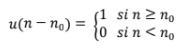

n = [-5 -4 -3 -2 -1  0  1  2  3  4  5]
x = [False False False False False  True  True  True  True  True  True]


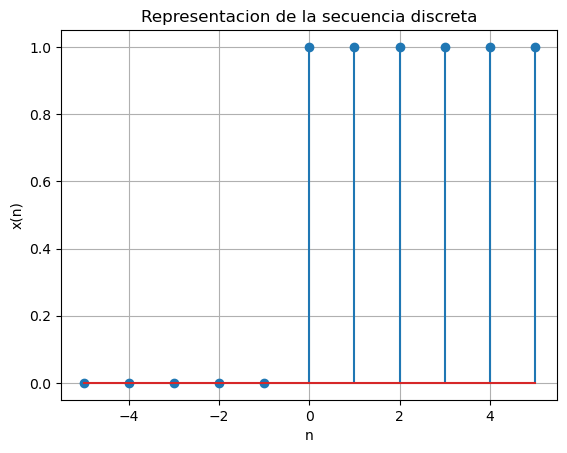

In [68]:
def escalon_unitario(n0, n1,n2):

    """ genera una señal escalon unitario de la fomr x(n) = u(n-n0); n1 <= n <= n2
        Donde n0: instante donde empieza el escalon, 
        n1: inicio del intervalo de observacion 
        n2: final del intervalo de observacion """
    
    n=np.arange(n1, n2+1) # crea vector de muestras, se le suma el 1 al n2 ya que el arange toma un n2-1 entonces se le suma para que el ultimo dato sea n2
    x = n >= n0 #Evalua elemento por elemento si n es mayor o igual a n0, si es asi devuelve un 1, si no devuelve un 0, entonces se obtiene el escalon unitario 
    return x, n # n: eje discreto x:valores de la señal

x,n = escalon_unitario(0,-5,5) # escalon empiza en 0, n1=-5 
print("n =", n)
print("x =", x)

#graficar 
 
plt.stem(n,x)
plt.xlabel('n')
plt.ylabel('x(n)')
plt.title('Representacion de la secuencia discreta')
plt.grid(True)
plt.show()

2. Implemente una función en Python que permita generar una función rampa, definida en un intervalo n1≤n0≤n2 con una pendiente m.

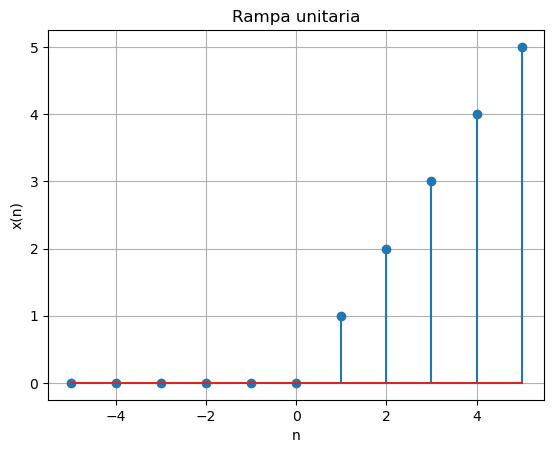

In [69]:
def rampa(n0,n1,n2,m=1):
    """ genera una señal rampa de la forma x(n) = m*(n-n0)*u(n-n0); n1 <= n0 <= n2
        Donde n0: instante donde empieza la rampa, 
        n1: inicio del intervalo de observacion 
        n2: final del intervalo de observacion 
        m: pendiente de la rampa (opcional, por defecto es 1)"""
    
    n= np.arange(n1, n2+1) # crea vector de muestras
    r= m * (n-n0) * (n>=n0) # se obtiene la rampa multiplicando la pendiente por el valor de n-n0 y por el escalon unitario para que solo se active a partir de n0
    return r, n

r, n = rampa(0, -5, 5, m=1)

#graficar 
 
plt.stem(n, r)
plt.xlabel('n')
plt.ylabel('x(n)')
plt.title('Rampa unitaria')
plt.grid()
plt.show()

3. Implemente una función en Python que permita generar una función exponencial compleja, definida en un intervalo n1≤n0≤n2.

Las exponenciales complejas son de la forma: x(n) = e^(σ+jω0)n, ∀ n

En la que σ produce una atenuación si es negativo o una amplificación si es positivo. En Python se hace uso del comando np exp.

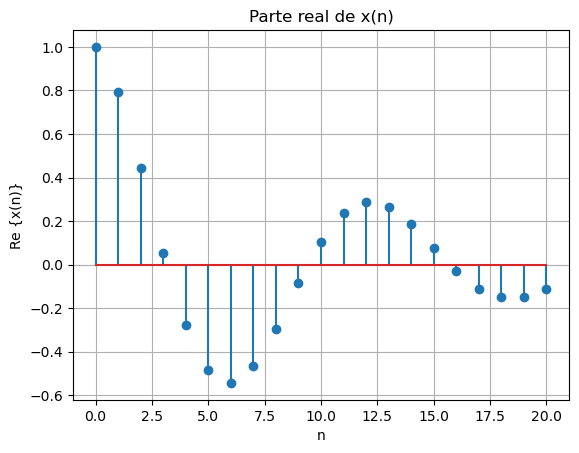

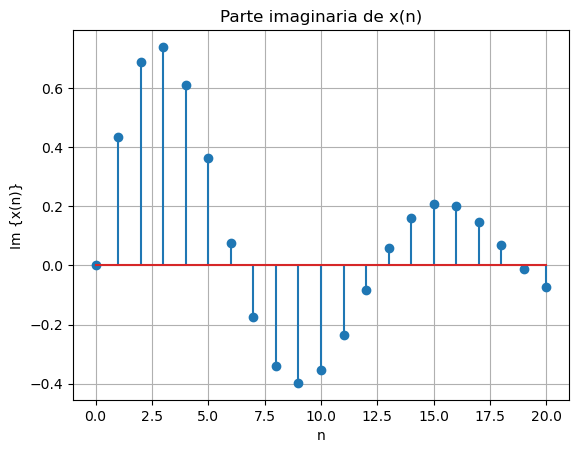

In [70]:
def exponencialCompleja(sigma, omega, n1, n2):

    """ genera una señal exponencial compleja de la forma x(n) = e^(sigma + j*omega)*n; n1 <= n <= n2. 
        Donde sigma: parte real de la exponencial, controla el crecimiento o atenuación de la señal,
        omega: frecuencia angular de la parte imaginaria, 
        n1: inicio del intervalo de observacion, 
        n2: final del intervalo de observacion"""

    n = np.arange(n1, n2+1)
    x = np.exp((sigma+1j*omega) * n) #np.exp calcula euler a la potencia dada, en este caso e^(sigma + j*omega)*n
    return x,n # x:señal compleja n:eje discreto

x, n = exponencialCompleja(-0.1, 0.5, 0, 20) 
#sigma = -0.1 señal amortiguada (decreciente), omega = 0.5 oscilación (controla la vel de oscilación), n = 0...20 ventana de observacion
#Si σ < 0 amortiguada (estable), Si σ = 0 amplitud constante (sin atenuación), Si σ > 0 crece (inestable)

#graficar 
 
plt.stem(n, np.real(x))
plt.xlabel('n')
plt.ylabel('Re {x(n)}')
plt.title('Parte real de x(n)')
plt.grid()
plt.show()

plt.stem(n, np.imag(x))
plt.xlabel('n')
plt.ylabel('Im {x(n)}')
plt.title('Parte imaginaria de x(n)')
plt.grid()
plt.show()


4. Implemente una función en Python que permita generar una función sinusoidal, definida en un intervalo n1≤n0≤n2.

Estas secuencias son de la forma: x(n) = sin (ω0n + θ0)

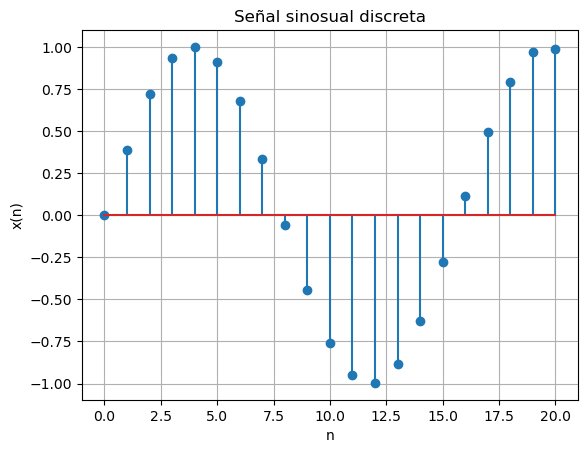

In [71]:
def secSin(omega0, theta0, n1, n2): 

    """ genera una señal sinusoidal discreta de la forma x(n) = sin(omega0*n + theta0); n1 <= n <= n2.
        Donde omega0: frecuencia angular de la señal,
        theta0: fase inicial de la señal,
        n1: inicio del intervalo de observacion,
        n2: final del intervalo de observacion"""

    n = np.arange(n1, n2+1)
    x = np.sin(omega0*n + theta0) # si theta0 = 0 la señal empieza en 0, si theta0 > 0 la señal se adelanta, si theta0 < 0 la señal se atrasa
    return x, n

x, n = secSin(0.4, 0, 0, 20)

#grafica

plt.stem(n,x)
plt.xlabel('n')
plt.ylabel('x(n)')
plt.title('Señal sinosual discreta')
plt.grid()
plt.show()

5. Genere las siguientes secuencias usando las funciones básicas de Python que se han presentado.

Grafique los resultados.

a. x1(n) = 3δ(n + 1) + 5δ(n + 3) + 3δ(n + 2) + 3δ(n) + δ(n). ¿Cómo debe ser el vector de muestras?

b. x4(n) = 2r(n + 3) − r(n − 2) − 5u(n − 3), −10 ≤ n ≤ 10

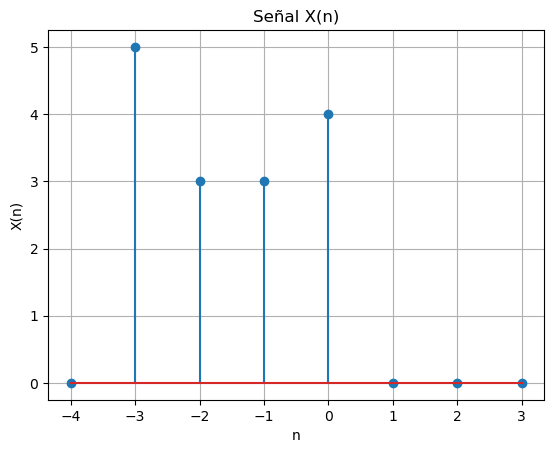

In [72]:
#a. Secuencia de impulsos con la funcion impseq


#3delta(n+1)
x, n = impseq(-1, -4, 3) #impulso en n=-1, intervalo de observacion de -4 a 3

#5delta(n+3)
x1, _ = impseq(-3, -4, 3) 

#3delta(n+2)
x2, _ = impseq(-2, -4, 3)

#3delta(n)
x3, _ = impseq(0, -4, 3)

#delta(n)
x4, _ =impseq(0, -4, 3)

#Señal resultante de la suma de los impulsos anteriores
X = (3*(x) + 5*(x1) + 3*(x2) + 3*(x3) + 1*(x4))
#Secuencia de impulsos con amplitudes 3 en n=-1, 5 en n=-3, 3 en n=-2, 3 en n=0 y 1 en n=0 (se suman los impulsos en n=0)

#grafica

plt.stem(n, X)
plt.xlabel("n")
plt.ylabel("X(n)")
plt.title("Señal X(n)")
plt.grid()
plt.show()



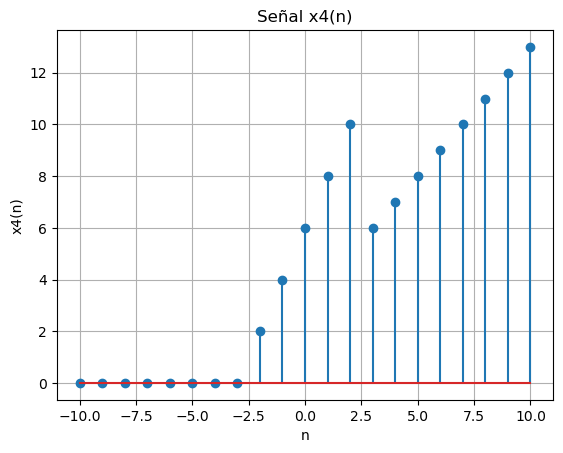

In [73]:
#b. Secuencia rampa, escalón y combinación lineal de ambas usando funciones rampa y escalón unitario

# r(n+3)
r1, n = rampa(-3, -10, 10)

# r(n-2)
r2, _ = rampa(2, -10, 10)

# escalón u(n-3)
u, _= escalon_unitario(3, -10, 10) #Es importante colocar _ para que solo me entreguen un n

# señal completa
x4 = 2*r1 - r2 - 5*u


#grafica

plt.stem(n, x4)
plt.xlabel("n")
plt.ylabel("x4(n)")
plt.title("Señal x4(n)")
plt.grid()
plt.show()

6. Genere la siguiente secuencia

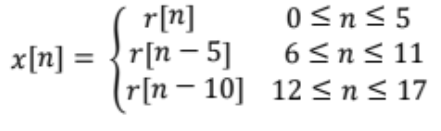

a. Derive la secuencia
b. Realice un subplot con las dos secuencias, la original, y la derivada. 
Describa lo que observa y el porqué no es exactamente la derivada del caso continuo.

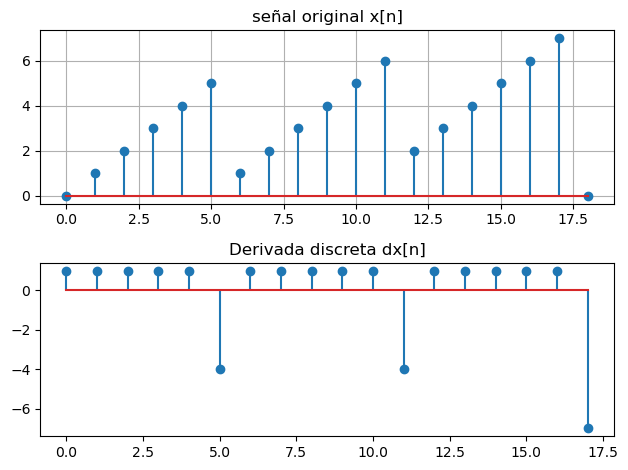

In [74]:

# Generar rampas completas en ese intervalo
r1, n = rampa(0, 0, 18)     # r[n]
r2, _ = rampa(5, 0, 18)     # r[n-5]
r3, _ = rampa(10, 0, 18)    # r[n-10]

# Inicializar señal
x = np.zeros(len(n))

# Asignar por tramos
x[(n >= 0) & (n <= 5)]   = r1[(n >= 0) & (n <= 5)]
x[(n >= 6) & (n <= 11)]  = r2[(n >= 6) & (n <= 11)]
x[(n >= 12) & (n <= 17)] = r3[(n >= 12) & (n <= 17)]

# Derivada discreta
dx = np.diff(x) # np.diff calcula la diferencia entre elementos consecutivos, lo que equivale a la derivada discreta
#grafica

plt.subplot(2, 1, 1)
plt.stem(n, x)
plt.title("señal original x[n]")
plt.grid()

plt.subplot(2, 1, 2)
plt.stem(n[:-1], dx) # n[:-1] se usa para ajustar el eje n a la longitud de dx, ya que dx tiene una muestra menos que x porque es la diferencia entre elementos consecutivos
plt.title("Derivada discreta dx[n]")
plt.grid

plt.tight_layout()
plt.show()

7. Sea x(n) = {0,1,2,3,4, 5̂, 4,3,2,1,0,1,2,3,4,5,5,5,5,10,10,10,10}. 

Genere la secuencia anterior y grafique los resultados. Use las funciones que generó antes para generar la secuencia concatenando secuencias más simples. Además encuentre las siguientes secuencias:

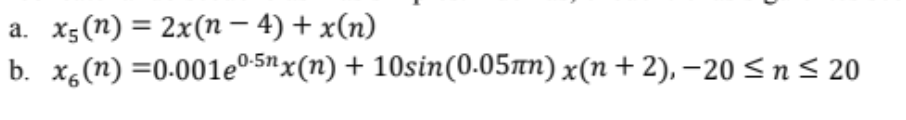

Conclusión: Tres conclusiones